In [1]:
## core packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
## Image handling
import splitfolders
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [3]:
## Model
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dense

In [4]:
splitfolders.ratio(
    "sick",        # input folder
    output="dataset",  # output folder
    seed=42,
    ratio=(0.8, 0.1, 0.1)  # train, val, test
)

In [6]:
train_datagen = ImageDataGenerator(
    rescale = 1./255,
    horizontal_flip=True,
    vertical_flip=True,
    rotation_range=20,
    zoom_range=0.1,
    brightness_range = (0.8,1.2),
    fill_mode = 'nearest'
)

val_datagen = ImageDataGenerator(
    rescale = 1./255
)

test_datagen = ImageDataGenerator(
    rescale = 1./255
)

In [7]:
train_generator = train_datagen.flow_from_directory(
    'dataset/train',
    target_size = (224,224),
    batch_size = 32,
    class_mode = 'binary'
   
)

val_generator = val_datagen.flow_from_directory(
    'dataset/train',
    target_size = (224,224),
    batch_size = 32,
    class_mode = 'binary'
    
)

test_generator = test_datagen.flow_from_directory(
    'dataset/train',
    target_size = (224,224),
    batch_size = 32,
    class_mode = 'binary'
  
)

Found 454 images belonging to 2 classes.
Found 454 images belonging to 2 classes.
Found 454 images belonging to 2 classes.


In [8]:
train_generator.class_indices

{'Negative': 0, 'Positive': 1}

In [9]:
## check batches

images, labels = next(train_generator)
print(images.shape, labels.shape)


(32, 224, 224, 3) (32,)


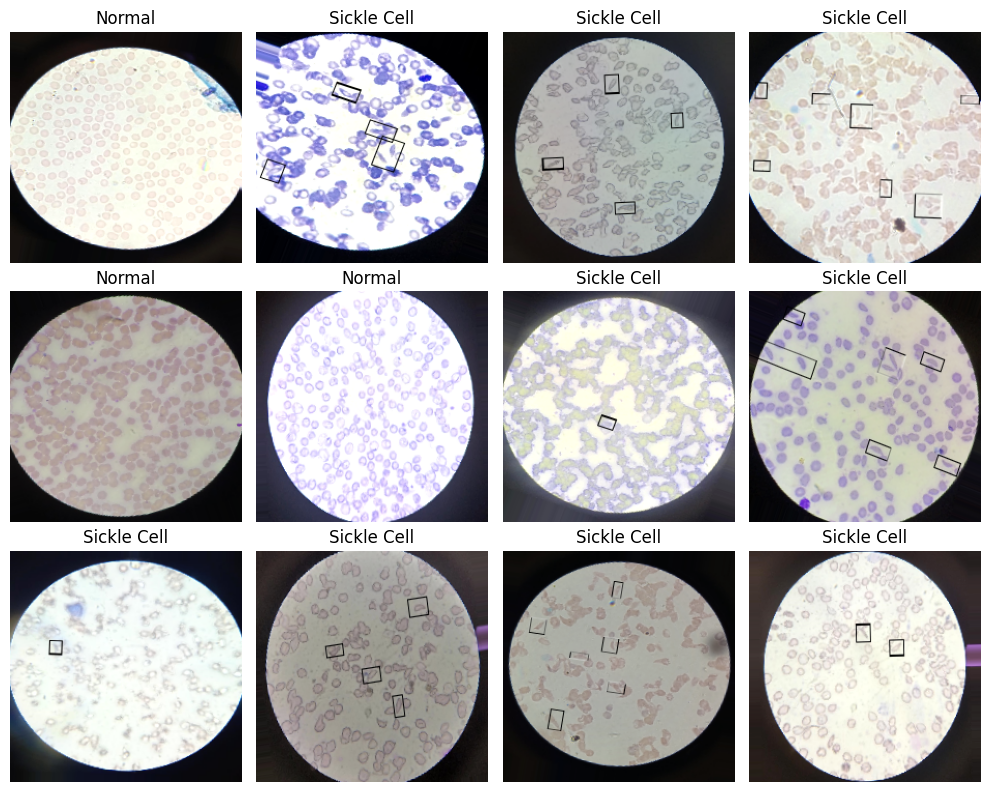

In [25]:
plt.figure(figsize=(10,8))
for i in range(min(12, len(images))):
    ax = plt.subplot(3, 4, i+1)
    
    # images are usually normalized (0-1), scale back for display
    plt.imshow(images[i])
    
    # For binary classification, labels might be 0 or 1
    label_text = "Sickle Cell" if labels[i] > 0.5 else "Normal"
    plt.title(label_text)
    
    plt.axis("off")

plt.tight_layout()
plt.show()

In [10]:
images[0]

array([[[0.08627451, 0.06666667, 0.0509804 ],
        [0.08627451, 0.06666667, 0.0509804 ],
        [0.08627451, 0.06666667, 0.0509804 ],
        ...,
        [0.07843138, 0.0627451 , 0.04705883],
        [0.07843138, 0.0627451 , 0.04705883],
        [0.09019608, 0.07058824, 0.05882353]],

       [[0.08627451, 0.06666667, 0.0509804 ],
        [0.08627451, 0.06666667, 0.0509804 ],
        [0.08627451, 0.06666667, 0.0509804 ],
        ...,
        [0.07843138, 0.0627451 , 0.04705883],
        [0.08627451, 0.06666667, 0.0509804 ],
        [0.09019608, 0.07058824, 0.05882353]],

       [[0.08627451, 0.06666667, 0.0509804 ],
        [0.08627451, 0.06666667, 0.0509804 ],
        [0.08627451, 0.06666667, 0.0509804 ],
        ...,
        [0.07843138, 0.0627451 , 0.04705883],
        [0.08627451, 0.06666667, 0.0509804 ],
        [0.09019608, 0.07058824, 0.05882353]],

       ...,

       [[0.09019608, 0.07058824, 0.05882353],
        [0.09019608, 0.07058824, 0.05882353],
        [0.09019608, 0

In [11]:
base_model = DenseNet121(include_top=False, weights='imagenet', input_shape=(224,224,3))


In [12]:
for layer in base_model.layers:
    layer.trainable = False

In [13]:
inputs = Input(shape=(224,224,3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
outputs = Dense(1, activation='sigmoid')(x)

model = Model(inputs, outputs)

In [15]:
## compile
model.compile(
    optimizer = 'adam',
    loss = 'binary_crossentropy',
    metrics = ['accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,168,833 (27.35 MB)

 Trainable params: 131,329 (513.00 KB)

 Non-trainable params: 7,037,504 (26.85 MB)

In [22]:
history = model.fit(
    train_generator,
    validation_data = val_generator,
    epochs=20
)

Epoch 1/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 53s 4s/step - accuracy: 0.9978 - loss: 0.0057 - val_accuracy: 1.0000 - val_loss: 0.0068
Epoch 2/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 65s 4s/step - accuracy: 0.9978 - loss: 0.0054 - val_accuracy: 1.0000 - val_loss: 0.0120
Epoch 3/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 43s 3s/step - accuracy: 0.9978 - loss: 0.0059 - val_accuracy: 1.0000 - val_loss: 0.0044
Epoch 4/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 60s 4s/step - accuracy: 1.0000 - loss: 0.0039 - val_accuracy: 1.0000 - val_loss: 0.0036
Epoch 5/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 61s 4s/step - accuracy: 1.0000 - loss: 0.0037 - val_accuracy: 1.0000 - val_loss: 0.0035
Epoch 6/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 51s 4s/step - accuracy: 1.0000 - loss: 0.0027 - val_accuracy: 1.0000 - val_loss: 0.0050
Epoch 7/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 41s 3s/step - accuracy: 1.0000 - loss: 0.0029 - val_accuracy: 1.0000 - val_loss: 0.0029
Epoch 8/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 40s 3s/step - accuracy: 1.0000 - loss: 0.0021 - val_accuracy: 1.0000 - val_loss:

In [19]:
model.evaluate(test_generator)

15/15 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 1.0000 - loss: 0.0042


[0.004169981926679611, 1.0]

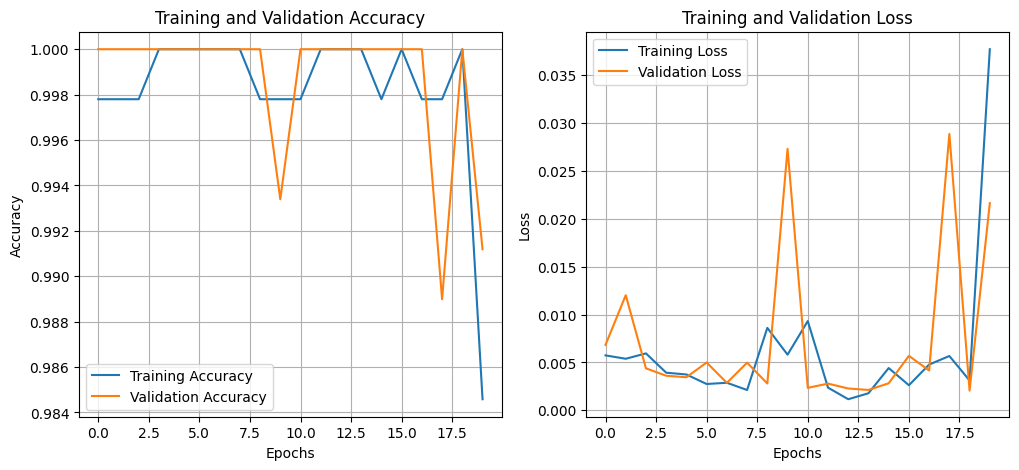

In [24]:
plt.figure(figsize=(12,5))

## plot accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

## plot loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

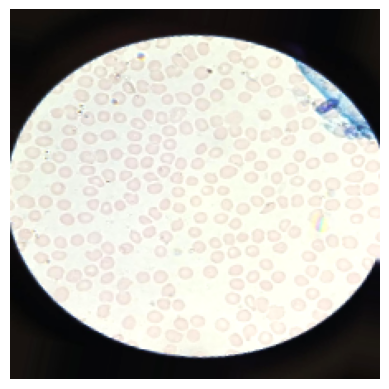

Actual label: Normal
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Predicted label: Normal
Confidence: 1.4132945e-07


In [26]:
first_image = images[0]  # shape: (224,224,3)
first_label = labels[0]  # 0 or 1 for binary

# Show the image
plt.imshow(first_image)
plt.axis("off")
plt.show()

# Print the actual label
label_text = "Sickle Cell" if first_label > 0.5 else "Normal"
print("Actual label:", label_text)

# Make prediction
prediction = model.predict(np.expand_dims(first_image, axis=0))  # add batch dimension
pred_label_text = "Sickle Cell" if prediction[0][0] > 0.5 else "Normal"
print("Predicted label:", pred_label_text)
print("Confidence:", prediction[0][0])

In [27]:
# Prediction function for a single image
def predict(model, img):
    # img is already a numpy array from ImageDataGenerator
    img_array = np.expand_dims(img, axis=0)  # create a batch
    prediction = model.predict(img_array)
    
    # For binary classification (sigmoid output)
    if prediction[0][0] > 0.5:
        predicted_class = "Sickle Cell"
    else:
        predicted_class = "Normal"
    
    confidence = round(100 * max(prediction[0][0], 1 - prediction[0][0]), 2)
    return predicted_class, confidence

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step


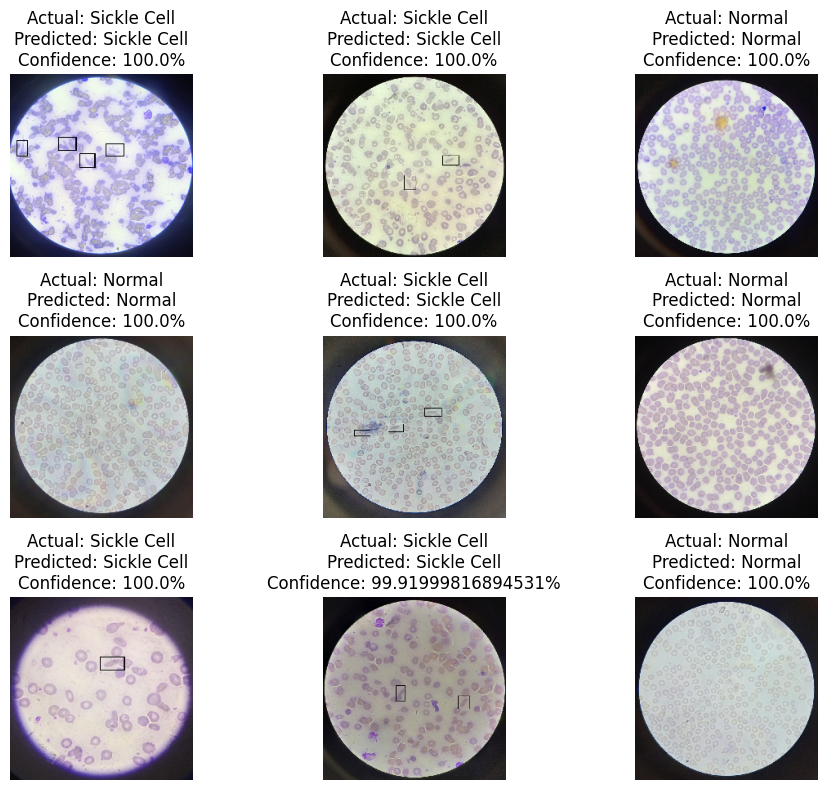

In [28]:
# Visualize predictions
plt.figure(figsize=(10,8))

# Get one batch from your test generator
images, labels = next(test_generator)  # test_generator = ImageDataGenerator.flow(...)

for i in range(9):  # show 9 images
    ax = plt.subplot(3,3, i+1)
    plt.imshow(images[i])
    
    predicted_class, confidence = predict(model, images[i])
    
    # Actual class
    actual_class = "Sickle Cell" if labels[i] > 0.5 else "Normal"
    
    plt.title(f"Actual: {actual_class}\nPredicted: {predicted_class}\nConfidence: {confidence}%")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [30]:
import os

model_dir = "./models"
os.makedirs(model_dir, exist_ok=True)

model_versions = [int(f) for f in os.listdir(model_dir) if f.isdigit()]
next_version = max(model_versions + [0]) + 1

save_path = os.path.join(model_dir, str(next_version))
model.export(save_path)  # Use export() for SavedModel folder

print(f"Model exported at: {save_path}")

INFO:tensorflow:Assets written to: ./models\1\assets


INFO:tensorflow:Assets written to: ./models\1\assets


Saved artifact at './models\1'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_427')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  2503475819120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2503476248640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2503476250576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2503475981728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2503475984016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2503476257088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2503476258848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2503476256384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2503476257616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2503476262544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2503476298848: TensorSpec(shape=(), 